In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3 Modalities Data**

In [2]:
data_multi = pd.read_csv("/Users/william/Desktop/ERP/data_multi.csv")
data_multi

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,Height,Weight,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,AgeGroup
0,3,145834,211552,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,...,175.3,269.240000,15.0,1.601220,0.40,80.772097,1,2,0,61-80
1,3,145834,211552,2101-10-24 21:00:00,6.0646,1,77.0,86.0,98.0,17.0,...,175.3,269.240000,15.0,1.549035,0.40,80.772097,1,2,0,61-80
2,3,145834,211552,2101-10-24 20:00:00,6.0646,1,77.0,85.0,99.0,17.0,...,175.3,269.240000,15.0,0.730116,0.40,105.000000,1,2,0,61-80
3,3,145834,211552,2101-10-24 19:00:00,6.0646,1,77.0,84.0,100.0,18.0,...,175.3,269.240000,15.0,1.471546,0.40,105.000000,1,2,0,61-80
4,3,145834,211552,2101-10-24 18:00:00,6.0646,1,77.0,88.0,100.0,17.0,...,175.3,269.240000,15.0,0.612001,0.40,105.000000,1,2,0,61-80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3072757,99999,113369,246512,2117-12-31 14:00:00,1.1242,0,64.0,98.0,97.0,18.0,...,161.3,75.416445,4.0,0.764668,0.21,69.524495,0,2,0,61-80
3072758,99999,113369,246512,2117-12-31 13:00:00,1.1242,0,64.0,94.0,97.0,15.0,...,161.3,75.416445,4.0,0.823122,0.21,69.524495,0,2,0,61-80
3072759,99999,113369,246512,2118-01-01 13:00:00,1.1242,0,64.0,86.0,97.0,15.0,...,161.3,75.416445,4.0,1.818850,0.21,69.524495,0,2,0,61-80
3072760,99999,113369,246512,2118-01-01 00:00:00,1.1242,0,64.0,100.0,97.0,21.0,...,161.3,75.416445,4.0,1.773556,0.21,69.524495,0,2,0,61-80


In [3]:
clinical = pd.read_csv("/Users/william/Desktop/ERP/Data/NOTEEVENTS.csv")

/var/folders/rr/7lt3z7lx0dv_6xh6d53km6980000gn/T/ipykernel_69971/964943495.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical = pd.read_csv("/Users/william/Desktop/ERP/Data/NOTEEVENTS.csv")


In [4]:
clinical = clinical.sort_values(by = "SUBJECT_ID")
clinical

,ROW_ID,SUBJECT_ID,HADM_ID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,CGID,ISERROR,TEXT
1671574,1678764,2,163353.0,2138-07-17,2138-07-17 22:51:00,2138-07-17 23:12:00,Nursing/other,Report,16929.0,NaN,Neonatology Attending Triage Note\n\nBaby [**N...
1671019,1678765,2,163353.0,2138-07-17,2138-07-17 23:08:00,2138-07-17 23:18:00,Nursing/other,Report,17774.0,NaN,Nursing Transfer note\n\n\nPt admitted to NICU...
291220,272794,3,NaN,2101-10-06,NaN,NaN,ECG,Report,NaN,NaN,Sinus rhythm\nInferior/lateral ST-T changes ar...
765778,769224,3,145834.0,2101-10-26,2101-10-26 06:01:00,NaN,Radiology,CHEST (PORTABLE AP),NaN,NaN,[**2101-10-26**] 6:01 AM\n CHEST (PORTABLE AP)...
291219,272793,3,NaN,2101-10-11,NaN,NaN,ECG,Report,NaN,NaN,Sinus rhythm\nA-V delay\nNonspecific inferior ...
...,...,...,...,...,...,...,...,...,...,...,...
719697,721970,99999,113369.0,2118-01-01,2118-01-01 13:01:00,2118-01-01 13:41:15,Nursing,Nursing Transfer Note,20685.0,NaN,63 yo F with history of neurogenic claudicatio...
719684,721770,99999,113369.0,2117-12-31,2117-12-31 17:39:00,2117-12-31 17:39:40,Nursing,Nursing Progress Note,21189.0,NaN,63 yo f POD1 PLIF L4-5 experienced episode of ...
718910,721728,99999,113369.0,2117-12-31,2117-12-31 14:04:00,2117-12-31 14:04:24,Physician,Physician Surgical Admission Note,16404.0,NaN,Chief Complaint: Respiratory distress\n HPI:...
719695,721967,99999,113369.0,2118-01-01,2118-01-01 13:01:00,2118-01-01 13:01:51,Nursing,Nursing Transfer Note,20685.0,NaN,63 yo F with history of neurogenic claudicatio...


In [5]:
clinical = clinical.dropna(subset= ["HADM_ID"])
clinical['CHARTDATE'] = pd.to_datetime(clinical['CHARTDATE']).dt.date


/var/folders/rr/7lt3z7lx0dv_6xh6d53km6980000gn/T/ipykernel_69971/1566207903.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clinical['CHARTDATE'] = pd.to_datetime(clinical['CHARTDATE']).dt.date


In [6]:
clinical['HADM_ID'] = clinical['HADM_ID'].astype(int)

/var/folders/rr/7lt3z7lx0dv_6xh6d53km6980000gn/T/ipykernel_69971/1288159632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clinical['HADM_ID'] = clinical['HADM_ID'].astype(int)


I drop CHARTTIME, STORETIME, and CGID(Care giver ID), which are not highly correlated to mortality

In [7]:
clinical = clinical.drop(columns=['CHARTTIME','STORETIME',"CGID","ISERROR"])

In [8]:
clinical

,ROW_ID,SUBJECT_ID,HADM_ID,CHARTDATE,CATEGORY,DESCRIPTION,TEXT
1671574,1678764,2,163353,2138-07-17,Nursing/other,Report,Neonatology Attending Triage Note\n\nBaby [**N...
1671019,1678765,2,163353,2138-07-17,Nursing/other,Report,Nursing Transfer note\n\n\nPt admitted to NICU...
765778,769224,3,145834,2101-10-26,Radiology,CHEST (PORTABLE AP),[**2101-10-26**] 6:01 AM\n CHEST (PORTABLE AP)...
765844,769043,3,145834,2101-10-24,Radiology,CHEST (PORTABLE AP),[**2101-10-24**] 8:05 AM\n CHEST (PORTABLE AP)...
765847,769130,3,145834,2101-10-25,Radiology,CHEST (PORTABLE AP),[**2101-10-25**] 6:32 AM\n CHEST (PORTABLE AP)...
...,...,...,...,...,...,...,...
718850,721872,99999,113369,2118-01-01,Physician,Intensivist Note,"SICU\n HPI:\n 63 F POD1 s/p PLIF, with res..."
719697,721970,99999,113369,2118-01-01,Nursing,Nursing Transfer Note,63 yo F with history of neurogenic claudicatio...
719684,721770,99999,113369,2117-12-31,Nursing,Nursing Progress Note,63 yo f POD1 PLIF L4-5 experienced episode of ...
718910,721728,99999,113369,2117-12-31,Physician,Physician Surgical Admission Note,Chief Complaint: Respiratory distress\n HPI:...


In [9]:
aggregated = (
    clinical.groupby(['CHARTDATE', 'HADM_ID', 'CATEGORY', 'DESCRIPTION'], as_index=False)
      .agg({
          'SUBJECT_ID': 'first',
          'TEXT': ' '.join
          
      })
)

aggregated = aggregated.sort_values(by = 'SUBJECT_ID')

In [10]:
aggregated

,CHARTDATE,HADM_ID,CATEGORY,DESCRIPTION,SUBJECT_ID,TEXT
338646,2138-07-17,163353,Nursing/other,Report,2,Neonatology Attending Triage Note\n\nBaby [**N...
9911,2101-10-26,145834,ECG,Report,3,Sinus rhythm\nP-R interval increased\nLate R w...
9853,2101-10-23,145834,Radiology,CHEST (PORTABLE AP),3,[**2101-10-23**] 5:22 AM\n CHEST (PORTABLE AP)...
9852,2101-10-23,145834,Nursing/other,Report,3,"MICU NPN 7PM-7AM:\nNeuro: Pt alert, follows co..."
9851,2101-10-23,145834,ECG,Report,3,Sinus rhythm\nLeft atrial abnormality\nNondiag...
...,...,...,...,...,...,...
150449,2118-01-04,113369,Discharge summary,Report,99999,Admission Date: [**2117-12-30**] ...
150352,2118-01-01,113369,Physician,Intensivist Note,99999,"SICU\n HPI:\n 63 F POD1 s/p PLIF, with res..."
150350,2118-01-01,113369,Nursing,Nursing Progress Note,99999,"Respiratory failure, acute (not ARDS/[**Doctor..."
150329,2117-12-31,113369,Nursing,Nursing Progress Note,99999,63 yo f POD1 PLIF L4-5 experienced episode of ...


In [11]:
data_multi

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,Height,Weight,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,AgeGroup
0,3,145834,211552,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,...,175.3,269.240000,15.0,1.601220,0.40,80.772097,1,2,0,61-80
1,3,145834,211552,2101-10-24 21:00:00,6.0646,1,77.0,86.0,98.0,17.0,...,175.3,269.240000,15.0,1.549035,0.40,80.772097,1,2,0,61-80
2,3,145834,211552,2101-10-24 20:00:00,6.0646,1,77.0,85.0,99.0,17.0,...,175.3,269.240000,15.0,0.730116,0.40,105.000000,1,2,0,61-80
3,3,145834,211552,2101-10-24 19:00:00,6.0646,1,77.0,84.0,100.0,18.0,...,175.3,269.240000,15.0,1.471546,0.40,105.000000,1,2,0,61-80
4,3,145834,211552,2101-10-24 18:00:00,6.0646,1,77.0,88.0,100.0,17.0,...,175.3,269.240000,15.0,0.612001,0.40,105.000000,1,2,0,61-80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3072757,99999,113369,246512,2117-12-31 14:00:00,1.1242,0,64.0,98.0,97.0,18.0,...,161.3,75.416445,4.0,0.764668,0.21,69.524495,0,2,0,61-80
3072758,99999,113369,246512,2117-12-31 13:00:00,1.1242,0,64.0,94.0,97.0,15.0,...,161.3,75.416445,4.0,0.823122,0.21,69.524495,0,2,0,61-80
3072759,99999,113369,246512,2118-01-01 13:00:00,1.1242,0,64.0,86.0,97.0,15.0,...,161.3,75.416445,4.0,1.818850,0.21,69.524495,0,2,0,61-80
3072760,99999,113369,246512,2118-01-01 00:00:00,1.1242,0,64.0,100.0,97.0,21.0,...,161.3,75.416445,4.0,1.773556,0.21,69.524495,0,2,0,61-80


In [12]:
data_multi = data_multi.dropna(subset= ["CHARTTIME"])

In [13]:
data_multi.isna().sum()

SUBJECT_ID                  0
HADM_ID                     0
ICUSTAY_ID                  0
CHARTTIME                   0
LOS                         0
GENDER                      0
AGE                         0
Heart Rate                  0
O2 Saturation               0
Respiratory Rate            0
Temperature (C)             0
Mean Blood Pressure         0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
WBC                         0
pH                          0
Glucose                     0
Sodium                      0
Potassium                   0
Creatinine                  0
BUN                         0
Hematocrit                  0
Height                      0
Weight                      0
GCS Total                   0
Lactic Acid                 0
FiO2                        0
PaO2                        0
ADMISSION_TYPE              0
INSURANCE                   0
HOSPITAL_EXPIRE_FLAG        0
AgeGroup                    0
dtype: int64

In [14]:
data_multi['CHARTTIME'] = pd.to_datetime(data_multi['CHARTTIME'], errors='coerce')
data_multi['CHARTDATE'] = data_multi['CHARTTIME'].dt.date
data_multi

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,Weight,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,AgeGroup,CHARTDATE
0,3,145834,211552,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,...,269.240000,15.0,1.601220,0.40,80.772097,1,2,0,61-80,2101-10-21
1,3,145834,211552,2101-10-24 21:00:00,6.0646,1,77.0,86.0,98.0,17.0,...,269.240000,15.0,1.549035,0.40,80.772097,1,2,0,61-80,2101-10-24
2,3,145834,211552,2101-10-24 20:00:00,6.0646,1,77.0,85.0,99.0,17.0,...,269.240000,15.0,0.730116,0.40,105.000000,1,2,0,61-80,2101-10-24
3,3,145834,211552,2101-10-24 19:00:00,6.0646,1,77.0,84.0,100.0,18.0,...,269.240000,15.0,1.471546,0.40,105.000000,1,2,0,61-80,2101-10-24
4,3,145834,211552,2101-10-24 18:00:00,6.0646,1,77.0,88.0,100.0,17.0,...,269.240000,15.0,0.612001,0.40,105.000000,1,2,0,61-80,2101-10-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3072757,99999,113369,246512,2117-12-31 14:00:00,1.1242,0,64.0,98.0,97.0,18.0,...,75.416445,4.0,0.764668,0.21,69.524495,0,2,0,61-80,2117-12-31
3072758,99999,113369,246512,2117-12-31 13:00:00,1.1242,0,64.0,94.0,97.0,15.0,...,75.416445,4.0,0.823122,0.21,69.524495,0,2,0,61-80,2117-12-31
3072759,99999,113369,246512,2118-01-01 13:00:00,1.1242,0,64.0,86.0,97.0,15.0,...,75.416445,4.0,1.818850,0.21,69.524495,0,2,0,61-80,2118-01-01
3072760,99999,113369,246512,2118-01-01 00:00:00,1.1242,0,64.0,100.0,97.0,21.0,...,75.416445,4.0,1.773556,0.21,69.524495,0,2,0,61-80,2118-01-01


In [15]:
data_multi['HADM_ID'] = data_multi['HADM_ID'].astype(int)

In [16]:
df_merged = data_multi.merge(clinical, on=["HADM_ID","SUBJECT_ID","CHARTDATE"], how = 'left')

In [17]:
df_merged

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,AgeGroup,CHARTDATE,ROW_ID,CATEGORY,DESCRIPTION,TEXT
0,3,145834,211552,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,...,80.772097,1,2,0,61-80,2101-10-21,1260684.0,Nursing/other,Report,Micu Progress Nursing Note:\n\nPatient arrived...
1,3,145834,211552,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,...,80.772097,1,2,0,61-80,2101-10-21,768885.0,Radiology,CHEST (PORTABLE AP),[**2101-10-21**] 4:43 PM\n CHEST (PORTABLE AP)...
2,3,145834,211552,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,...,80.772097,1,2,0,61-80,2101-10-21,768834.0,Radiology,CHEST (PORTABLE AP),[**2101-10-21**] 6:10 AM\n CHEST (PORTABLE AP)...
3,3,145834,211552,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,...,80.772097,1,2,0,61-80,2101-10-21,94503.0,Echo,Report,PATIENT/TEST INFORMATION:\nIndication: S/P Car...
4,3,145834,211552,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,...,80.772097,1,2,0,61-80,2101-10-21,94504.0,Echo,Report,PATIENT/TEST INFORMATION:\nIndication: Pericar...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15481554,99999,113369,246512,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,...,69.524495,0,2,0,61-80,2118-01-01,721867.0,Nursing,Nursing Progress Note,"Respiratory failure, acute (not ARDS/[**Doctor..."
15481555,99999,113369,246512,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,...,69.524495,0,2,0,61-80,2118-01-01,721895.0,Physician,Intensivist Note,"SICU\n HPI:\n 63 F POD1 s/p PLIF, with res..."
15481556,99999,113369,246512,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,...,69.524495,0,2,0,61-80,2118-01-01,721872.0,Physician,Intensivist Note,"SICU\n HPI:\n 63 F POD1 s/p PLIF, with res..."
15481557,99999,113369,246512,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,...,69.524495,0,2,0,61-80,2118-01-01,721970.0,Nursing,Nursing Transfer Note,63 yo F with history of neurogenic claudicatio...


In [18]:
df_merged = df_merged.drop(columns=["SUBJECT_ID","HADM_ID","ICUSTAY_ID","CHARTDATE","ROW_ID","AgeGroup"])

In [19]:
df_merged

,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,Temperature (C),Mean Blood Pressure,Systolic Blood Pressure,...,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,CATEGORY,DESCRIPTION,TEXT
0,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,Nursing/other,Report,Micu Progress Nursing Note:\n\nPatient arrived...
1,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,Radiology,CHEST (PORTABLE AP),[**2101-10-21**] 4:43 PM\n CHEST (PORTABLE AP)...
2,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,Radiology,CHEST (PORTABLE AP),[**2101-10-21**] 6:10 AM\n CHEST (PORTABLE AP)...
3,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,Echo,Report,PATIENT/TEST INFORMATION:\nIndication: S/P Car...
4,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,Echo,Report,PATIENT/TEST INFORMATION:\nIndication: Pericar...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15481554,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,Nursing,Nursing Progress Note,"Respiratory failure, acute (not ARDS/[**Doctor..."
15481555,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,Physician,Intensivist Note,"SICU\n HPI:\n 63 F POD1 s/p PLIF, with res..."
15481556,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,Physician,Intensivist Note,"SICU\n HPI:\n 63 F POD1 s/p PLIF, with res..."
15481557,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,Nursing,Nursing Transfer Note,63 yo F with history of neurogenic claudicatio...


In [20]:
df_merged.isna().sum()

CHARTTIME                        2
LOS                              0
GENDER                           0
AGE                              0
Heart Rate                       0
O2 Saturation                    0
Respiratory Rate                 0
Temperature (C)                  0
Mean Blood Pressure              0
Systolic Blood Pressure          0
Diastolic Blood Pressure         0
WBC                              0
pH                               0
Glucose                          0
Sodium                           0
Potassium                        0
Creatinine                       0
BUN                              0
Hematocrit                       0
Height                           0
Weight                           0
GCS Total                        0
Lactic Acid                      0
FiO2                             0
PaO2                             0
ADMISSION_TYPE                   0
INSURANCE                        0
HOSPITAL_EXPIRE_FLAG             0
CATEGORY            

In [21]:
df = df_merged.dropna()

In [22]:
df

,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,Temperature (C),Mean Blood Pressure,Systolic Blood Pressure,...,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,CATEGORY,DESCRIPTION,TEXT
0,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,Nursing/other,Report,Micu Progress Nursing Note:\n\nPatient arrived...
1,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,Radiology,CHEST (PORTABLE AP),[**2101-10-21**] 4:43 PM\n CHEST (PORTABLE AP)...
2,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,Radiology,CHEST (PORTABLE AP),[**2101-10-21**] 6:10 AM\n CHEST (PORTABLE AP)...
3,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,Echo,Report,PATIENT/TEST INFORMATION:\nIndication: S/P Car...
4,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,Echo,Report,PATIENT/TEST INFORMATION:\nIndication: Pericar...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15481554,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,Nursing,Nursing Progress Note,"Respiratory failure, acute (not ARDS/[**Doctor..."
15481555,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,Physician,Intensivist Note,"SICU\n HPI:\n 63 F POD1 s/p PLIF, with res..."
15481556,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,Physician,Intensivist Note,"SICU\n HPI:\n 63 F POD1 s/p PLIF, with res..."
15481557,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,Nursing,Nursing Transfer Note,63 yo F with history of neurogenic claudicatio...


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectors for the notes column
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_features = tfidf.fit_transform(df['TEXT']).toarray()

In [24]:
tfidf_features

array([[0.        , 0.        , 0.        , ..., 0.        , 0.40160612,
        0.16797955],
       [0.        , 0.        , 0.        , ..., 0.32893272, 0.        ,
        0.11288794],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.1004417 ],
       ...,
       [0.06455875, 0.        , 0.        , ..., 0.04887203, 0.04812005,
        0.        ],
       [0.10334499, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [25]:
from sklearn.preprocessing import LabelEncoder

# list your categorical columns
cat_cols = ["CATEGORY","DESCRIPTION"]

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

/var/folders/rr/7lt3z7lx0dv_6xh6d53km6980000gn/T/ipykernel_69971/3752779009.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col].astype(str))
/var/folders/rr/7lt3z7lx0dv_6xh6d53km6980000gn/T/ipykernel_69971/3752779009.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col].astype(str))


In [26]:
df

,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,Temperature (C),Mean Blood Pressure,Systolic Blood Pressure,...,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,CATEGORY,DESCRIPTION,TEXT
0,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,7,2263,Micu Progress Nursing Note:\n\nPatient arrived...
1,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,11,317,[**2101-10-21**] 4:43 PM\n CHEST (PORTABLE AP)...
2,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,11,317,[**2101-10-21**] 6:10 AM\n CHEST (PORTABLE AP)...
3,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,4,2263,PATIENT/TEST INFORMATION:\nIndication: S/P Car...
4,2101-10-21 11:00:00,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,...,15.0,1.601220,0.40,80.772097,1,2,0,4,2263,PATIENT/TEST INFORMATION:\nIndication: Pericar...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15481554,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,6,1411,"Respiratory failure, acute (not ARDS/[**Doctor..."
15481555,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,10,967,"SICU\n HPI:\n 63 F POD1 s/p PLIF, with res..."
15481556,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,10,967,"SICU\n HPI:\n 63 F POD1 s/p PLIF, with res..."
15481557,2118-01-01 10:00:00,1.1242,0,64.0,83.0,97.0,20.0,36.821877,88.750504,111.334241,...,4.0,0.615081,0.21,69.524495,0,2,0,6,1412,63 yo F with history of neurogenic claudicatio...


In [27]:
X = df.drop(columns=["HOSPITAL_EXPIRE_FLAG"], axis = 1)
y = df["HOSPITAL_EXPIRE_FLAG"]

In [28]:
X = X[['LOS', 'GENDER', 'AGE', 'Heart Rate', 'O2 Saturation',
       'Respiratory Rate', 'Temperature (C)', 'Mean Blood Pressure',
       'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'WBC', 'pH',
       'Glucose', 'Sodium', 'Potassium', 'Creatinine', 'BUN', 'Hematocrit',
       'Height', 'Weight', 'GCS Total', 'Lactic Acid', 'FiO2', 'PaO2',
       'ADMISSION_TYPE', 'INSURANCE']]

In [29]:
import numpy as np

X = np.hstack([X, tfidf_features])  # Shape: (n_samples, n_all_features)


In [30]:
X

array([[6.06460000e+00, 1.00000000e+00, 7.70000000e+01, ...,
        0.00000000e+00, 4.01606118e-01, 1.67979545e-01],
       [6.06460000e+00, 1.00000000e+00, 7.70000000e+01, ...,
        3.28932724e-01, 0.00000000e+00, 1.12887943e-01],
       [6.06460000e+00, 1.00000000e+00, 7.70000000e+01, ...,
        0.00000000e+00, 0.00000000e+00, 1.00441703e-01],
       ...,
       [1.12420000e+00, 0.00000000e+00, 6.40000000e+01, ...,
        4.88720349e-02, 4.81200493e-02, 0.00000000e+00],
       [1.12420000e+00, 0.00000000e+00, 6.40000000e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.12420000e+00, 0.00000000e+00, 6.40000000e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

**train_test_split**

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

## **Random Forest Classifier**

In [32]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier(max_depth= None, max_features="log2", min_samples_split = 4, n_estimators= 40, random_state=42, n_jobs=-1, bootstrap = False)
RFC.fit(X_train, y_train)

RandomForestClassifier(bootstrap=False, max_features='log2',
                       min_samples_split=4, n_estimators=40, n_jobs=-1,
                       random_state=42)

In [33]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score

y_predict_RFC = RFC.predict(X_test)

accuracy_RFC = accuracy_score(y_test, y_predict_RFC)
print("Accuracy rate for Random Forest Classifier:", accuracy_RFC)

auc_RFC = roc_auc_score(y_test, y_predict_RFC)
print(f"AUC = {auc_RFC:.3f}")

kappa_RFC = cohen_kappa_score(y_test, y_predict_RFC)
print(f"Cohen’s kappa for Random Forest Classifier: {kappa_RFC:.3f}")

report_RFC = classification_report(y_test, y_predict_RFC, digits=4)
print(report_RFC)

Accuracy rate for Random Forest Classifier: 0.9984311719792018
AUC = 0.995
Cohen’s kappa for Random Forest Classifier: 0.994
              precision    recall  f1-score   support

           0     0.9981    1.0000    0.9991   2531212
           1     0.9999    0.9908    0.9953    515011

    accuracy                         0.9984   3046223
   macro avg     0.9990    0.9954    0.9972   3046223
weighted avg     0.9984    0.9984    0.9984   3046223



Text(0.5, 1.0, 'Normalized Confusion Matrix for Random Forest Classifier')

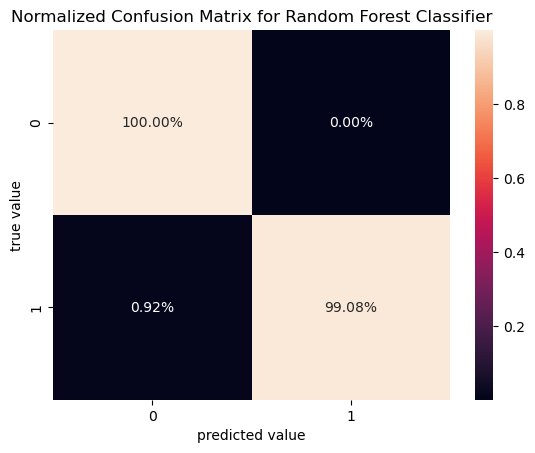

In [34]:
mat_RFC = confusion_matrix(y_test, y_predict_RFC, normalize='true')
sns.heatmap(mat_RFC, annot=True,fmt='.2%', cbar=True)
plt.xlabel('predicted value')
plt.ylabel('true value')
plt.title("Normalized Confusion Matrix for Random Forest Classifier")

Text(0, 0.5, 'Fraction of positives')

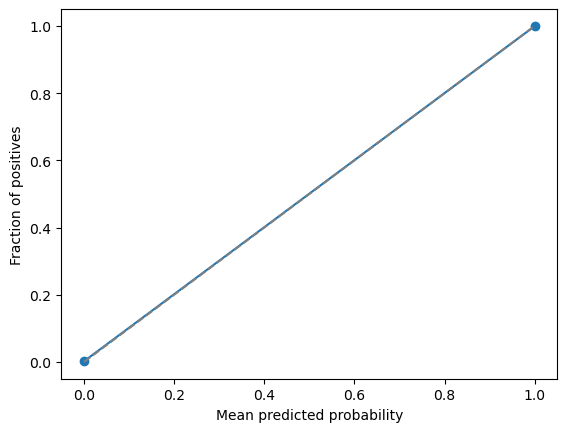

In [35]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_predict_RFC, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')

## **Decision Tree Classifer**

In [36]:
from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier(min_samples_split = 2, min_samples_leaf = 1, max_features = None, max_depth = None, class_weight = "balanced")
DTC.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced')

In [37]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score

y_predict_DTC = DTC.predict(X_test)

accuracy_DTC = accuracy_score(y_test, y_predict_DTC)
print("Accuracy Rate for Decision Tree classifier:", accuracy_DTC)

auc_DTC = roc_auc_score(y_test, y_predict_DTC)
print(f"AUC = {auc_DTC:.3f}")

kappa_DTC = cohen_kappa_score(y_test, y_predict_DTC)
print(f"Cohen’s kappa for Decision Tree classifier: {kappa_DTC:.3f}")


report_DTC = classification_report(y_test, y_predict_DTC, digits=4)
print(report_DTC)


Accuracy Rate for Decision Tree classifier: 0.9973258687889889
AUC = 0.995
Cohen’s kappa for Decision Tree classifier: 0.990
              precision    recall  f1-score   support

           0     0.9985    0.9983    0.9984   2531212
           1     0.9917    0.9925    0.9921    515011

    accuracy                         0.9973   3046223
   macro avg     0.9951    0.9954    0.9952   3046223
weighted avg     0.9973    0.9973    0.9973   3046223



Text(50.722222222222214, 0.5, 'True Value')

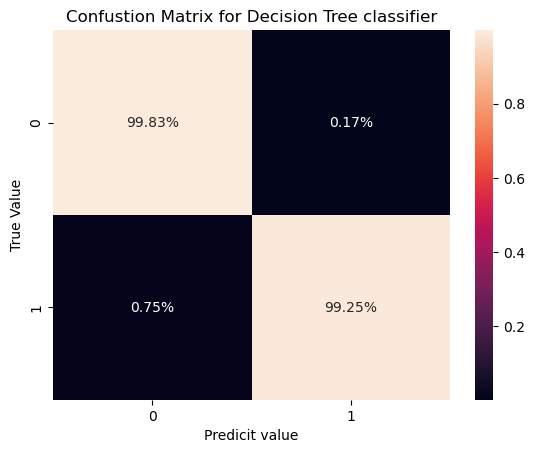

In [38]:
mat_DTC = confusion_matrix(y_test, y_predict_DTC, normalize = 'true')

sns.heatmap(mat_DTC, annot= True, fmt='.2%', cbar = True)
plt.title("Confustion Matrix for Decision Tree classifier")
plt.xlabel("Predicit value")
plt.ylabel("True Value")

Text(0, 0.5, 'Fraction of positives')

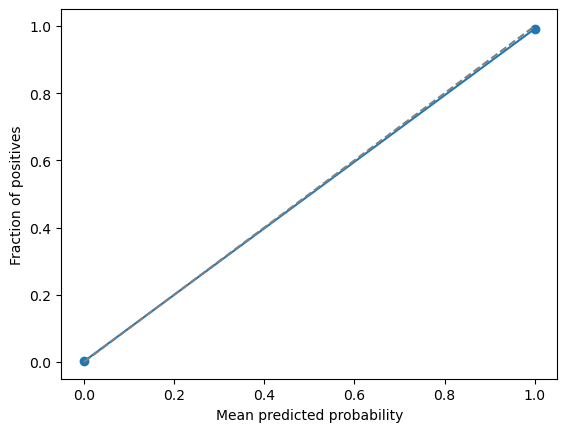

In [39]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_predict_DTC, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')

## **XGBoost**

In [36]:
from xgboost import XGBClassifier

XGB = XGBClassifier(
    colsmaple_bytree = 1.0,
    learning_rate = 0.1,
    gemma = 0.25,
    max_depth = 8, 
    n_estimators = 600,
    subsample = 0.7,
    eval_metric="logloss",
    random_state=42)

XGB.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:32:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "colsmaple_bytree", "gemma" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, colsmaple_bytree=1.0, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, gemma=0.25, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, ...)

In [37]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score


y_predict_XGB = XGB.predict(X_test)

accuracy_XGB = accuracy_score(y_test, y_predict_XGB)
print("Accuracy Rate for XGboost classifier: ", accuracy_XGB)


auc_XGB = roc_auc_score(y_test, y_predict_XGB)
print(f"AUC = {auc_XGB:.3f}")

kappa_XGB = cohen_kappa_score(y_test, y_predict_XGB)
print(f"Cohen’s kappa: {kappa_XGB:.3f}")


report_XGB = classification_report(y_test, y_predict_XGB, digits=4)
print(report_XGB)


Accuracy Rate for XGboost classifier:  0.9843800010701778
AUC = 0.956
Cohen’s kappa: 0.943
              precision    recall  f1-score   support

           0     0.9827    0.9987    0.9907   2531212
           1     0.9932    0.9138    0.9519    515011

    accuracy                         0.9844   3046223
   macro avg     0.9880    0.9563    0.9713   3046223
weighted avg     0.9845    0.9844    0.9841   3046223



Text(50.722222222222214, 0.5, 'True Value')

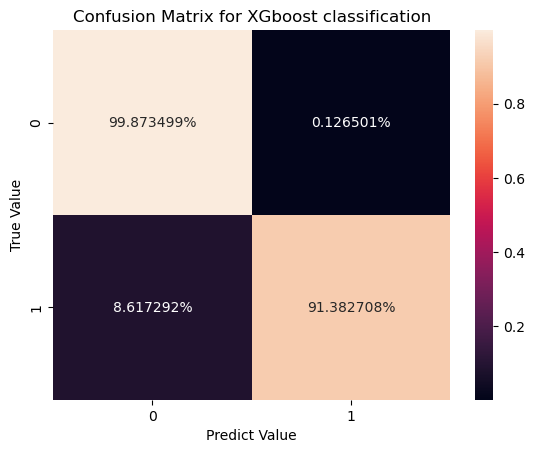

In [38]:
mat_XGB = confusion_matrix(y_test, y_predict_XGB, normalize = 'true')

sns.heatmap(mat_XGB, annot = True, fmt= '2%', cbar = True)
plt.title("Confusion Matrix for XGboost classification")
plt.xlabel("Predict Value")
plt.ylabel("True Value")

Text(0, 0.5, 'Fraction of positives')

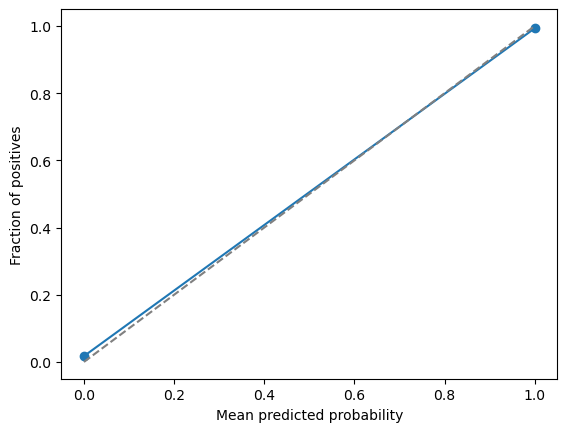

In [39]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_predict_XGB, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')